# Does a Coinbase listing really make a coin pop — and then give it all back? 🚀
### The "Coinbase effect", measured on 129 real listings — in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Gone_before_you_can_act%3F: Confirmed](https://img.shields.io/badge/Gone_before_you_can_act%3F-Confirmed-8b949e?style=flat-square)

Crypto folklore says that when Coinbase — the biggest regulated US exchange — announces it will list a coin, the coin **jumps double digits** on the news… and then **bleeds it all back** over the following weeks. It even has a name: the **Coinbase effect**. There was a real US criminal case about people front-running these announcements (the first crypto insider-trading conviction), so somebody clearly believed the pop was worth cheating for.

We measured it properly: **129 Coinbase listings, 2019–2026**, with prices from Binance — where these coins already trade long before Coinbase adds them.

> 📓 **Plain-language layer.** Want the *t*-stats, placebos and cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Honesty note up front.** Returns are measured **relative to Bitcoin** (so a market-wide crypto rally doesn't get credited to the listing), and the event dates come from Coinbase's **own API** (the first day each coin actually traded there), not from hand-picked headlines. Every chart is drawn by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from exchange_listing_pop import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    EV = data.events_frame()
    EV = EV[EV["coin"].isin(PX.columns)].reset_index(drop=True)
    ABN = st.abnormal_returns(PX)
else:
    PX = EV = ABN = None
print("real cache present:", HAVE_REAL,
      "| events:", (0 if EV is None else len(EV)),
      "| panel:", (None if PX is None else PX.shape))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2017-08-17', 'end': '2026-07-02', 'years': 8.9, 'days': 3242, 'n_coins': 134, 'n_events': 129, 'n_clusters': 95, 'n_pre': 56, 'n_post': 73, 'windows': [('early run-up [-20..-6]', -20, -6, 2.4, 2.43, 1.25), ('run-up [-5..-1]', -5, -1, 10.23, 10.77, 5.91), ('listing day [0]', 0, 0, 0.77, 0.77, 0.82), ('THE POP [-5..0]', -5, 0, 11.0, 11.63, 5.74), ('post [+1..+5]', 1, 5, -6.14, -5.96, -3.93), ('THE FADE [+1..+30]', 1, 30, -17.45, -16.02, -5.73)], 'pop': {'car': 11.0, 't': 5.74, 't_month': 5.3, 'med': 7.11, 'share_pos': 76, 'obs_event': 14.6, 'welch': 6.92, 'p': '< 0.0005', 'n_pooled': 188947}, 'fade': {'car': -17.45, 't': -5.73, 't_month': -4.96, 'med': -17.97, 'share_pos': 19, 'obs_event': -16.79, 'welch': -4.38, 'p': '< 0.0005', 'n_pooled': 185676}, 'era': {'pre_pop': 17.17, 'pre_pop_t': 5.52, 'post_pop': 7.06, 'post_pop_t': 3.06, 'pre_fade': -16.98, 'pre_fade_t': -3.95, 'post_fade': -17.76, 'post_fade_t': -4.23, 'diff_welch': 2.61, 'n_pre_cl': 37, 'n_post_cl': 58}, 'long_tr': [(5, 10, -4.58, -2.59, -5.03, -2.84, 19), (5, 25, -4.58, -2.59, -5.63, -3.17, 17), (5, 50, -4.58, -2.59, -6.63, -3.74, 14), (30, 10, -11.97, -3.92, -12.61, -4.13, 18), (30, 25, -11.97, -3.92, -13.21, -4.33, 18), (30, 50, -11.97, -3.92, -14.21, -4.66, 18)], 'short_tr': [(10, 11.97, 3.92, 10.74, 3.52, 79), (25, 11.97, 3.92, 10.14, 3.32, 76), (50, 11.97, 3.92, 9.14, 3.0, 75)], 'borrow': [(10, 10.14, 3.32, 76), (50, 6.86, 2.25, 74), (100, 2.75, 0.9, 67)], 'gaps': [('MATIC', '2021-03-09', '2021-03-11', 2), ('ADA', '2021-03-16', '2021-03-18', 2), ('DOGE', '2021-06-01', '2021-06-03', 2), ('SOL', '2021-05-20', '2021-06-17', 28)], 'syn': [(0.0, 0.0, 0.41, 0.21, 2.89, 0.7), (15.0, 10.0, 15.41, 7.71, -7.11, -1.73)], 'fingerprint': 'f6a046325f17'}


real cache present: True | events: 129 | panel: (3242, 135)


## The answer first

| Question | Answer |
|---|---|
| Does the pop exist? | **Yes, emphatically.** On average a coin gains **~+11% vs Bitcoin** in the week into its Coinbase listing — across 129 events, far too consistently to be luck (odds well under 1 in 2,000). |
| Does it give it back? | **Yes — and then some.** Over the next 30 days the average coin loses **~−17% vs Bitcoin**. The hangover is *bigger* than the party. |
| Can *you* catch the pop? | **No.** Almost all of it happens **between the announcement and the first trade** — before you can click buy. The listing day itself adds less than +1%. Buying at the first possible close then holding a month lost **−12.6% net** on average. |
| So is there *any* trade? | Only the uncomfortable one: **shorting** the freshly listed coin — about **+10% net per event** on paper — *if* you can actually borrow a hot new altcoin, which is exactly where borrowing is scarce and expensive. |

> The folklore is **true as a description** and a **trap as an instruction**. The pop is real; it just isn't *yours*.

## 1 · The claim

> *"Getting listed on Coinbase is a golden ticket: the coin pops double digits on the announcement — then gives it all back."*

The mechanism is plausible: a Coinbase listing (a) opens the coin to a huge pool of US buyers who couldn't easily hold it before, and (b) works as a **stamp of approval** (Coinbase reviews assets before listing). Both fire **when the news drops** — not when trading starts. Messari's research desk quantified the pop in 2020–21; the DOJ's *U.S. v. Wahi* case (2022) proved insiders traded on it; Coinbase answered with a public **listing roadmap** (April 2022) meant to kill the information edge. Our question: what's left, and for whom?

## 2 · So what?

If the pop were catchable, it would be one of the easiest trades in crypto: watch the Coinbase blog, buy, wait, sell. If instead it's **priced before you can act**, then the folklore — endlessly repeated as a buying strategy — is actually a **wealth transfer** from the people who buy the news to the people who front-ran it. And if the *give-back* is real too, buying the news isn't just late — it's buying the top of a mountain.

## 3 · How would we even know?

- **Events.** 129 Coinbase listings 2019–2026. Day 0 = the first day the coin's USD book traded on Coinbase Exchange, straight from **Coinbase's own API** — no hand-curated dates. A price-agreement check between venues kills ticker mix-ups.
- **Prices.** Binance daily closes (9 years, 134 coins + BTC) — the coins trade there *months or years before* Coinbase lists them, so we can see the before, the during and the after.
- **Measure.** Each coin's return **minus Bitcoin's** (so "crypto went up that week" doesn't count), averaged across events, with same-day listings grouped (Coinbase often announces several coins in one post).
- **Then:** compare the days *before* the listing, the listing day, and the month after.

## 4 · The teardown — one chart tells the whole story

Average cumulative return vs Bitcoin from 20 days before the Coinbase listing to 30 days after, across all events. Watch where the mountain peaks.

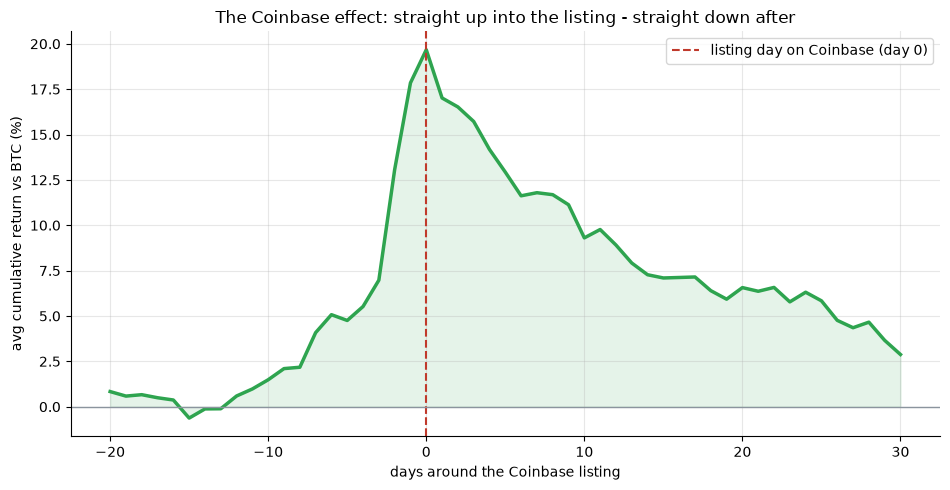

peak around day 0: +19.7%   day +30: +2.9%


In [2]:
if HAVE_REAL:
    M = st.event_matrix(ABN, EV, -20, 30)
    path = M.mean(axis=1).cumsum() * 100
else:
    path = None
fig, ax = plt.subplots(figsize=(9.6, 5.0))
if path is not None:
    ax.plot(path.index, path.values, lw=2.5, color=GREEN)
    ax.fill_between(path.index, 0, path.values, alpha=.12, color=GREEN)
ax.axvline(0, ls='--', c=RED, lw=1.5, label='listing day on Coinbase (day 0)')
ax.axhline(0, c=GREY, lw=1)
ax.set_xlabel('days around the Coinbase listing'); ax.set_ylabel('avg cumulative return vs BTC (%)')
ax.set_title('The Coinbase effect: straight up into the listing - straight down after')
ax.legend(); plt.tight_layout(); plt.show()
if path is not None:
    print(f'peak around day 0: {path.loc[0]:+.1f}%   day +30: {path.loc[30]:+.1f}%')

There's the legend, drawn by the tape. Measured from 20 days out, the average coin climbs ~+20% vs Bitcoin into its listing — with the headline chunk, **+11%**, packed into the final five days — then gives **~-17 points back** over the month after. The mountain peaks **almost exactly at day 0** — the first day you could actually buy on Coinbase.

**Zoom in: when exactly does the pop happen?** Split the event into the run-up, the listing day itself, and the aftermath.

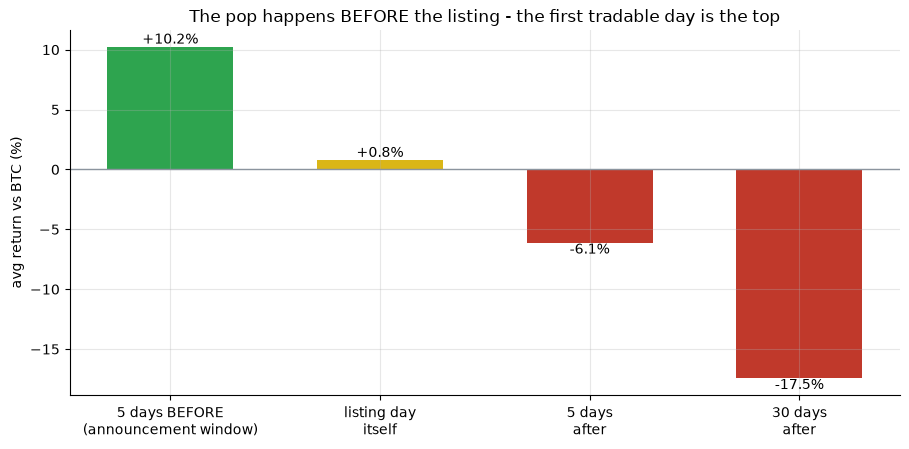

run-up / day0 / +5d / +30d: ['+10.2%', '+0.8%', '-6.1%', '-17.5%']


In [3]:
if HAVE_REAL:
    segs = [st.window_summary(ABN, EV, a, b) for a, b in [(-5, -1), (0, 0), (1, 5), (1, 30)]]
    vals = [s['mean_car'] * 100 for s in segs]
else:
    vals = [R['windows'][1][3], R['windows'][2][3], R['windows'][4][3], R['windows'][5][3]]
labels = ['5 days BEFORE\n(announcement window)', 'listing day\nitself', '5 days\nafter', '30 days\nafter']
colors = [GREEN, AMBER, RED, RED]
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.bar(labels, vals, color=colors, width=.6)
for i, v in enumerate(vals): ax.annotate(f'{v:+.1f}%', (i, v), ha='center',
        va='bottom' if v > 0 else 'top')
ax.axhline(0, c=GREY, lw=1)
ax.set_ylabel('avg return vs BTC (%)')
ax.set_title('The pop happens BEFORE the listing - the first tradable day is the top')
plt.tight_layout(); plt.show()
print('run-up / day0 / +5d / +30d:', [f'{v:+.1f}%' for v in vals])

> The green bar — **+10.2%** — happens in the few days between the announcement and the first trade (2 days apart in the old regime: DOGE was announced June 1, 2021 and tradable June 3). The **listing day itself adds just +0.8%** — statistically nothing. By the time *you* can buy, the move has already been made by people who acted on the announcement — or before it.

**So what happens if you buy anyway?** The only version of the trade available to a normal person: buy at the close of the listing day, hold, measured against Bitcoin, after realistic fees.

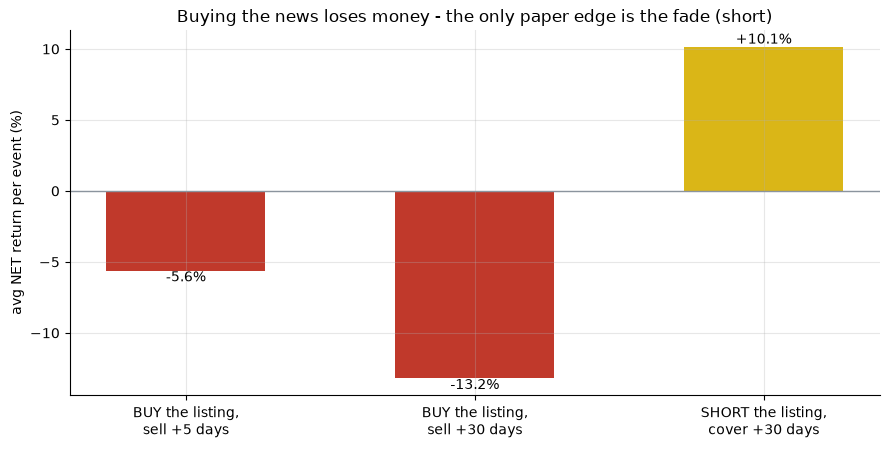

net per event: ['-5.6%', '-13.2%', '+10.1%'] (25 bps/leg, shorts pay borrow)


In [4]:
if HAVE_REAL:
    rows = [st.trade_summary(st.follower_trade(PX, EV, hold=h, cost_bps=25.0, hedged=True))
            for h in (5, 30)]
    vals = [r['net_pct'] for r in rows]
    sh = st.trade_summary(st.follower_trade(PX, EV, hold=30, cost_bps=25.0, hedged=True, side='short'))
    short_net = sh['net_pct']
else:
    vals = [R['long_tr'][1][4], R['long_tr'][4][4]]; short_net = R['short_tr'][1][3]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
bars = ['BUY the listing,\nsell +5 days', 'BUY the listing,\nsell +30 days', 'SHORT the listing,\ncover +30 days']
vv = [vals[0], vals[1], short_net]
ax.bar(bars, vv, color=[RED, RED, AMBER], width=.55)
for i, v in enumerate(vv): ax.annotate(f'{v:+.1f}%', (i, v), ha='center', va='bottom' if v > 0 else 'top')
ax.axhline(0, c=GREY, lw=1)
ax.set_ylabel('avg NET return per event (%)')
ax.set_title('Buying the news loses money - the only paper edge is the fade (short)')
plt.tight_layout(); plt.show()
print('net per event:', [f'{v:+.1f}%' for v in vv], '(25 bps/leg, shorts pay borrow)')

Buying the listing and holding a month lost **-13.2% net per event** on average — and lost in **82%** of cases. The only trade the tape actually pays is the **fade**: short the freshly listed coin, hedge with Bitcoin, collect **+10.1% net** on paper. The catch: you must **borrow** a hot, just-listed altcoin to short it — precisely the coins that are hard and expensive to borrow. At 100%/yr borrow the edge is gone. Real, but only for whoever has the borrow — which is probably not you.

## 5 · The verdict

- **Signal — Real.** The pop (**+11%** vs BTC) and the give-back (**-17%**) are both on the tape at overwhelming significance across 129 listings. The folklore describes reality.
- **Tradability — Fragile.** The folklore's *instruction* (buy the news) loses **-13.2% net** per event. The mirror trade (short it) makes **+10.1%** on paper but lives or dies on borrowing a hot new altcoin.
- **"Gone before you can act?" — Confirmed.** +10.2 pp of the pop happens before the first tradable day; the listing day adds +0.8%. And since Coinbase's 2022 transparency roadmap, the pop has **halved** (+17% → +7%).

## 6 · Going further 🚪

- **The equity ancestor.** The same story existed in stocks — the S&P 500 inclusion pop ([study 249](../../249-index-inclusion/)) — and died once everyone front-ran the front-runners. Crypto is speed-running the same decay: the pop already halved after Coinbase's 2022 roadmap policy.
- **Why does the fade exceed the pop?** New listings arrive at peak attention. Attention fades, early holders take profit into the new demand, and the coin drifts back — the same "buy the rumor, sell the news" asymmetry as IPOs and index inclusions.
- **The insider chapter is real law now.** *U.S. v. Wahi* (2022): a Coinbase employee tipped listings to relatives — the first crypto insider-trading conviction. The pop was literally worth going to prison for. That tells you where in the timeline the money is.

*Think you can borrow freshly-listed alts at scale and harvest the fade? Show the borrow quotes — then we'll talk.*